In [74]:
import pickle

shape_plot_data_path = '../plots/border_cam_cue_conflict_shape_plot_data.pkl'
with open(shape_plot_data_path, 'rb') as f:
    shape_plot_data = pickle.load(f)

texture_plot_data_path = '../plots/border_cam_cue_conflict_texture_plot_data.pkl'
with open(texture_plot_data_path, 'rb') as f:
    texture_plot_data = pickle.load(f)

In [75]:
import pandas as pd

df_matched_shape = shape_plot_data['df_matched']
df_matched_texture = texture_plot_data['df_matched']
df_ood_shape = shape_plot_data['df_ood']
df_ood_texture = texture_plot_data['df_ood']

In [76]:
df_matched_shape['Value'].fillna(df_matched_shape['Value'].mean(), inplace=True)
df_matched_texture['Value'].fillna(df_matched_texture['Value'].mean(), inplace=True)
df_ood_shape['Value'].fillna(df_ood_shape['Value'].mean(), inplace=True)
df_ood_texture['Value'].fillna(df_ood_texture['Value'].mean(), inplace=True)

# df_matched_shape['Type'] = df_matched_shape['View'].astype(str) + "_Shape"
# df_matched_texture['Type'] = df_matched_texture['View'].astype(str) + "_Texture"
# df_ood_shape['Type'] = df_ood_shape['View'].astype(str) + "_Shape"
# df_ood_texture['Type'] = df_ood_texture['View'].astype(str) + "_Texture"
df_matched_shape['Type'] = "Shape"
df_matched_texture['Type'] = "Texture"
df_ood_shape['Type'] = "Shape"
df_ood_texture['Type'] = "Texture"


df_matched = pd.concat([df_matched_shape, df_matched_texture], ignore_index=True)
df_ood = pd.concat([df_ood_shape, df_ood_texture], ignore_index=True)

In [77]:
df_matched_shape.head()

,CAM Type,View,Value,Type
0,ic,f,0.663074,Shape
1,ic,f,0.502641,Shape
2,ic,f,0.656601,Shape
3,ic,f,0.534787,Shape
4,ic,f,0.738138,Shape


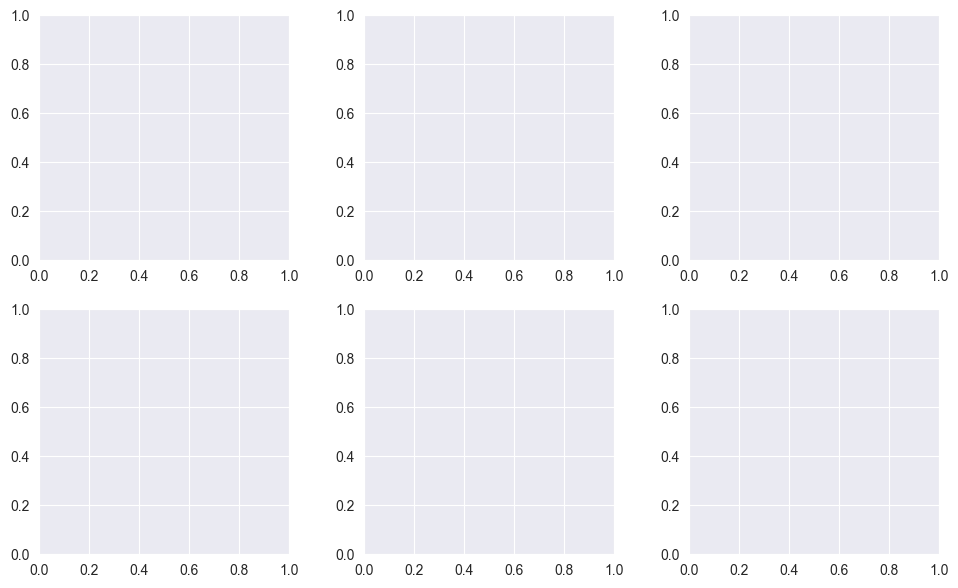

In [78]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
fig.subplots_adjust(left=0.1, right=0.85, wspace=0.3)

/var/folders/v7/jkm5bzbj4yq0t2lxv86qvb5m0000gn/T/ipykernel_2874/1282632194.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1, ind_cam].set_xticklabels(view_plot_name)
/var/folders/v7/jkm5bzbj4yq0t2lxv86qvb5m0000gn/T/ipykernel_2874/1282632194.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1, ind_cam].set_xticklabels(view_plot_name)
/var/folders/v7/jkm5bzbj4yq0t2lxv86qvb5m0000gn/T/ipykernel_2874/1282632194.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1, ind_cam].set_xticklabels(view_plot_name)


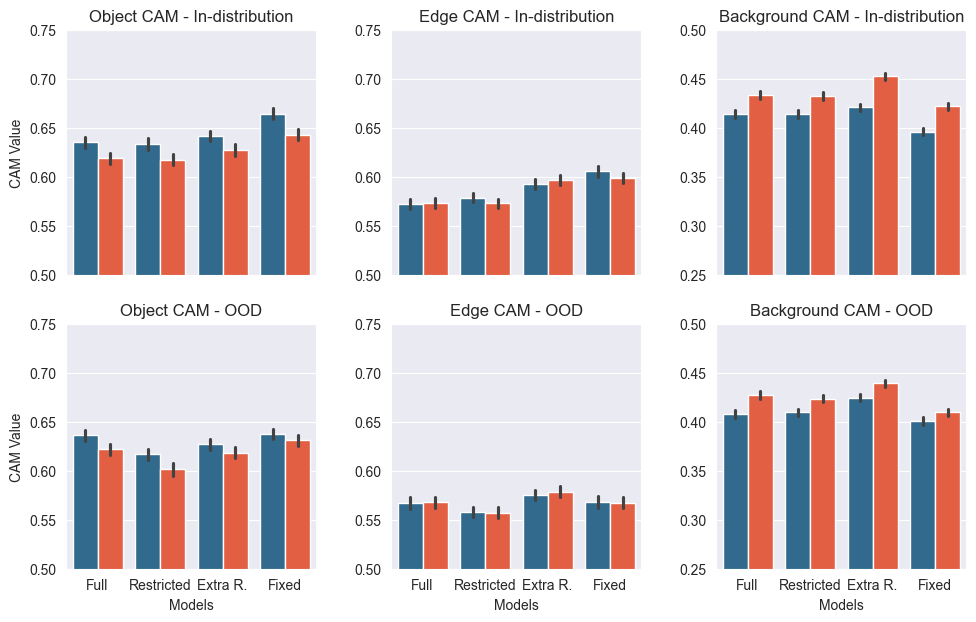

In [79]:
import numpy as np
import seaborn as sns

palette = {
    'Shape': '#226E9C',
    'Texture': '#FC4E2A',
}
cam_types = {
    0: 'ic',
    1: 'bc',
    2: 'ec',
}
cam_names = {
    'ic': 'Object',
    'bc': 'Edge',
    'ec': 'Background',
}
view_plot_name = ["Full", "Restricted", "Extra R.", "Fixed"]

for ind_cam in range(3):
    cam_type = cam_types[ind_cam]
    sns.barplot(ax=axes[0, ind_cam], x='View', y='Value', hue='Type', data=df_matched[df_matched['CAM Type'] == cam_type], palette=palette, legend=False)
    sns.barplot(ax=axes[1, ind_cam], x='View', y='Value', hue='Type',  data=df_ood[df_ood['CAM Type'] == cam_type], palette=palette, legend=False)
    
    axes[0, ind_cam].set_xlabel("")
    axes[0, ind_cam].set_xticks([])
    axes[0, ind_cam].set_title(f'{cam_names[cam_type]} CAM - In-distribution')
    axes[0, ind_cam].set_ylim(0.5, 0.75)
    axes[0, ind_cam].set_xlabel("")
    axes[0, ind_cam].set_xticks([])
    axes[1, ind_cam].set_title(f'{cam_names[cam_type]} CAM - OOD')
    axes[1, ind_cam].set_ylim(0.5, 0.75)
    axes[1, ind_cam].set_xlabel("Models")
    axes[1, ind_cam].set_xticklabels(view_plot_name)
    axes[0, ind_cam].set_ylabel("")
    axes[1, ind_cam].set_ylabel("")
    if ind_cam == 0:
        axes[0, ind_cam].set_ylabel("CAM Value")
        axes[1, ind_cam].set_ylabel("CAM Value")
    if ind_cam == 2:
        axes[0, ind_cam].set_ylim(0.25, 0.5)
        axes[1, ind_cam].set_ylim(0.25, 0.5)

fig

In [ ]:
# Split the dataframe by CAM Type
df_ic = df_matched[df_matched['CAM Type'] == 'ic'][['View', 'Type', 'Value']].rename(columns={'Value': 'ic'})
df_bc = df_matched[df_matched['CAM Type'] == 'bc'][['View', 'Type', 'Value']].rename(columns={'Value': 'bc'})
df_ec = df_matched[df_matched['CAM Type'] == 'ec'][['View', 'Type', 'Value']].rename(columns={'Value': 'ec'})

# Concatenate the parts horizontally
df_wide = pd.concat([df_ic.reset_index(drop=True), df_bc.reset_index(drop=True), df_ec.reset_index(drop=True)], axis=1)
# Merge columns with the same name and identical values
df_wide = df_wide.loc[:, ~df_wide.columns.duplicated()]
df_wide.head()

In [ ]:
sns.scatterplot(data=df_wide, x='ic', y='ec', hue='View')

In [ ]:
# Split the dataframe by CAM Type
df_ic = df_ood[df_ood['CAM Type'] == 'ic'][['View', 'Type', 'Value']].rename(columns={'Value': 'ic'})
df_bc = df_ood[df_ood['CAM Type'] == 'bc'][['View', 'Type', 'Value']].rename(columns={'Value': 'bc'})
df_ec = df_ood[df_ood['CAM Type'] == 'ec'][['View', 'Type', 'Value']].rename(columns={'Value': 'ec'})

# Concatenate the parts horizontally
df_wide = pd.concat([df_ic.reset_index(drop=True), df_bc.reset_index(drop=True), df_ec.reset_index(drop=True)], axis=1)
# Merge columns with the same name and identical values
df_wide = df_wide.loc[:, ~df_wide.columns.duplicated()]
df_wide.head()

In [1]:
data_path = f'../plots/border_cam_plot_data.pkl'
with open(data_path, 'rb') as f:
    plot_data = pickle.load(f)
df_matched = plot_data['df_matched']
df_ood = plot_data['df_ood']

NameError: name 'pickle' is not defined

In [87]:
# Pivoting the dataframe to wide format
df_mean_matched = df_matched_shape.pivot_table(index=["View", "Type", "CAM Type"], values="Value", aggfunc='median').reset_index().drop('Type', axis=1)
df_mean_ood = df_ood_shape.pivot_table(index=["View", "Type", "CAM Type"], values="Value", aggfunc='median').reset_index().drop('Type', axis=1)

In [94]:
df_heatmap_matched = df_mean_matched.pivot(index="CAM Type", columns="View", values="Value")
df_heatmap_ood = df_mean_ood.pivot(index="CAM Type", columns="View", values="Value")

In [98]:
model_order = ['f', 'r', 'er', 'fx']
df_heatmap_matched = df_heatmap_matched[model_order]
df_heatmap_ood = df_heatmap_ood[model_order]

<Axes: xlabel='View', ylabel='CAM Type'>

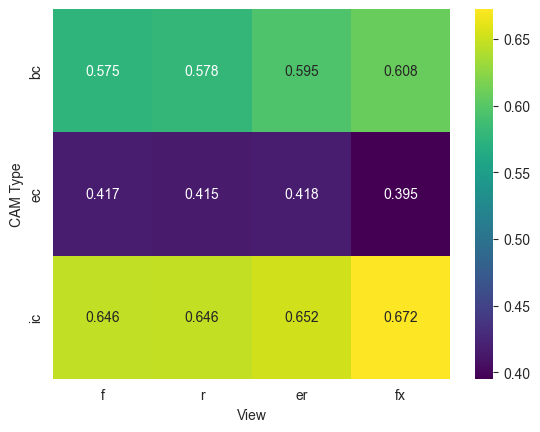

In [101]:
sns.heatmap(df_heatmap_matched, cmap='viridis', annot=True, fmt='.3f')

<Axes: xlabel='View', ylabel='CAM Type'>

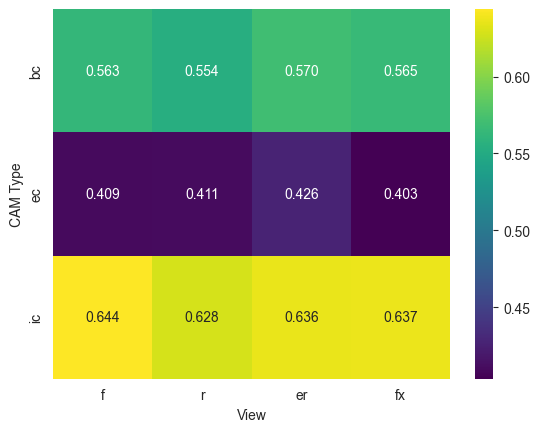

In [102]:
sns.heatmap(df_heatmap_ood, cmap='viridis', annot=True, fmt='.3f')

In [105]:
df_heatmap_matched = df_mean_matched.pivot(index="View", columns="CAM Type", values="Value")
df_heatmap_ood = df_mean_ood.pivot(index="View", columns="CAM Type", values="Value")

In [107]:
df_heatmap_matched['cong_c'] = df_heatmap_matched['ic'] - df_heatmap_matched['bc'] + 1

In [108]:
df_heatmap_matched

CAM Type,bc,ec,ic,cong_c
View,,,,
er,0.595248,0.417841,0.651751,1.056503
f,0.575362,0.416670,0.646299,1.070936
fx,0.608235,0.395148,0.672290,1.064055
r,0.578238,0.415300,0.646358,1.068120


In [109]:
df_heatmap_ood['cong_c'] = df_heatmap_ood['ic'] - df_heatmap_ood['bc'] + 1

In [110]:
df_heatmap_ood

CAM Type,bc,ec,ic,cong_c
View,,,,
er,0.570233,0.426008,0.635695,1.065461
f,0.563032,0.409177,0.643883,1.080851
fx,0.565397,0.403467,0.636859,1.071462
r,0.553913,0.410506,0.628033,1.074120
